In [1]:
!pip install -q transformers pytesseract pillow faiss-cpu scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 66.5 MB/s eta 0:00:00:00:0100:01


In [5]:
DATA_DIR = "/kaggle/input/datasets/uditamin/rvl-cdip-small/data"


In [8]:
!pip install -q pymupdf


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 69.8 MB/s eta 0:00:00:00:0100:01


**creating new embeddings**

In [20]:
DATA_DIR = "/kaggle/input/datasets/uditamin/rvl-cdip-small/data"
SAVE_DIR = "/kaggle/working"

ALL_LABELS = [
    "advertisement",
    "invoice",
    "scientific publication",
    "news article",
    "resume"
]

BATCH_SIZE = 16   # DiT allows larger batches
device = "cuda" if torch.cuda.is_available() else "cpu"


In [22]:
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("microsoft/dit-base")
model = AutoModel.from_pretrained("microsoft/dit-base").to(device)
model.eval()


preprocessor_config.json:   0%|          | 0.00/302 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/369M [00:00<?, ?B/s]

Some weights of BeitModel were not initialized from the model checkpoint at microsoft/dit-base and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BeitModel(
  (embeddings): BeitEmbeddings(
    (patch_embeddings): BeitPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): BeitEncoder(
    (layer): ModuleList(
      (0): BeitLayer(
        (attention): BeitAttention(
          (attention): BeitSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=False)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): BeitSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): BeitIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActiv

model.safetensors:   0%|          | 0.00/368M [00:00<?, ?B/s]

In [23]:
def encode_batch(image_paths):
    images = [Image.open(p).convert("RGB") for p in image_paths]

    inputs = processor(images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    # DiT CLS token
    embeddings = outputs.last_hidden_state[:, 0, :]
    return embeddings.cpu().numpy()


In [24]:
X, y = [], []
label2id, id2label = {}, {}
label_id = 0

for class_name in ALL_LABELS:
    print(f"\n📂 Processing {class_name}")

    label2id[class_name] = label_id
    id2label[label_id] = class_name

    class_path = os.path.join(DATA_DIR, class_name)
    files = [f for f in os.listdir(class_path) if f.endswith(".tif")]
    random.shuffle(files)

    split_idx = int(0.8 * len(files))
    train_files = files[:split_idx]

    for i in tqdm(range(0, len(train_files), BATCH_SIZE)):
        batch = train_files[i:i+BATCH_SIZE]
        paths = [os.path.join(class_path, f) for f in batch]

        emb = encode_batch(paths)
        X.extend(emb)
        y.extend([label_id] * len(batch))

    label_id += 1



📂 Processing advertisement


100%|██████████| 150/150 [01:08<00:00,  2.20it/s]



📂 Processing invoice


100%|██████████| 150/150 [00:55<00:00,  2.70it/s]



📂 Processing scientific publication


100%|██████████| 150/150 [00:57<00:00,  2.60it/s]



📂 Processing news article


100%|██████████| 150/150 [00:47<00:00,  3.15it/s]



📂 Processing resume


100%|██████████| 151/151 [00:45<00:00,  3.32it/s]


In [26]:
import zipfile
import os
X = np.array(X, dtype="float32")
y = np.array(y)

faiss.normalize_L2(X)

np.save(f"{SAVE_DIR}/train_embeddings.npy", X)
np.save(f"{SAVE_DIR}/train_labels.npy", y)
np.save(f"{SAVE_DIR}/label2id.npy", label2id)
np.save(f"{SAVE_DIR}/id2label.npy", id2label)

index = faiss.IndexFlatIP(X.shape[1])
index.add(X)
faiss.write_index(index, f"{SAVE_DIR}/faiss_index.bin")

print("✅ DiT embeddings + FAISS index saved")


zip_path = f"{SAVE_DIR}/dit_faiss_embeddings.zip"

files_to_zip = [
    f"{SAVE_DIR}/train_embeddings.npy",
    f"{SAVE_DIR}/train_labels.npy",
    f"{SAVE_DIR}/label2id.npy",
    f"{SAVE_DIR}/id2label.npy",
    f"{SAVE_DIR}/faiss_index.bin",
]

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_zip:
        zipf.write(file, arcname=os.path.basename(file))

print(f"✅ ZIP file created at: {zip_path}")


✅ DiT embeddings + FAISS index saved
✅ ZIP file created at: /kaggle/working/dit_faiss_embeddings.zip


In [39]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt


In [40]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_CLASSES = 5
BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3


In [41]:
X_train = np.load("/kaggle/working/train_embeddings.npy")
y_train = np.load("/kaggle/working/train_labels.npy")

X_test = np.load("/kaggle/working/test_embeddings.npy")
y_test = np.load("/kaggle/working/test_labels.npy")

id2label = np.load(
    "/kaggle/working/id2label.npy", allow_pickle=True
).item()

print("Train distribution:", Counter(y_train))
print("Test distribution :", Counter(y_test))


Train distribution: Counter({np.int64(4): 2403, np.int64(3): 2400, np.int64(0): 2395, np.int64(1): 2393, np.int64(2): 2388})
Test distribution : Counter({np.int64(3): 601, np.int64(4): 601, np.int64(0): 599, np.int64(1): 599, np.int64(2): 597})


In [42]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
y_train = torch.tensor(y_train, dtype=torch.long).to(DEVICE)

X_test = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(DEVICE)


In [43]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(X_train.shape[1], NUM_CLASSES).to(DEVICE)


In [44]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


In [45]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train.cpu().numpy()),
    y=y_train.cpu().numpy()
)

weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=LR)


In [46]:
print("\n🚀 Training started...\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss:.4f}")



🚀 Training started...

Epoch 01/25 | Loss: 280.7675
Epoch 02/25 | Loss: 217.6619
Epoch 03/25 | Loss: 177.8382
Epoch 04/25 | Loss: 161.5983
Epoch 05/25 | Loss: 154.3360
Epoch 06/25 | Loss: 146.7460
Epoch 07/25 | Loss: 141.5176
Epoch 08/25 | Loss: 135.9186
Epoch 09/25 | Loss: 132.4890
Epoch 10/25 | Loss: 127.1742
Epoch 11/25 | Loss: 123.5226
Epoch 12/25 | Loss: 117.6153
Epoch 13/25 | Loss: 113.6512
Epoch 14/25 | Loss: 108.8911
Epoch 15/25 | Loss: 104.3354
Epoch 16/25 | Loss: 101.9285
Epoch 17/25 | Loss: 98.3464
Epoch 18/25 | Loss: 97.5140
Epoch 19/25 | Loss: 96.4764
Epoch 20/25 | Loss: 93.7633
Epoch 21/25 | Loss: 89.2791
Epoch 22/25 | Loss: 89.6220
Epoch 23/25 | Loss: 88.8300
Epoch 24/25 | Loss: 89.4710
Epoch 25/25 | Loss: 84.7561


In [47]:
torch.save(model.state_dict(), "/kaggle/working/mlp_classifier.pth")
print("✅ Model saved")


✅ Model saved


In [48]:
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, y_pred = torch.max(outputs, 1)

y_pred = y_pred.cpu().numpy()

print("\nPrediction distribution:", Counter(y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[id2label[i] for i in sorted(id2label)]
    )
)



Prediction distribution: Counter({np.int64(1): 855, np.int64(0): 622, np.int64(3): 596, np.int64(4): 475, np.int64(2): 449})

Accuracy: 0.8118118118118118

Classification Report:

                        precision    recall  f1-score   support

         advertisement       0.83      0.86      0.84       599
               invoice       0.69      0.98      0.81       599
scientific publication       0.96      0.72      0.82       597
          news article       0.75      0.74      0.75       601
                resume       0.95      0.75      0.84       601

              accuracy                           0.81      2997
             macro avg       0.84      0.81      0.81      2997
          weighted avg       0.84      0.81      0.81      2997



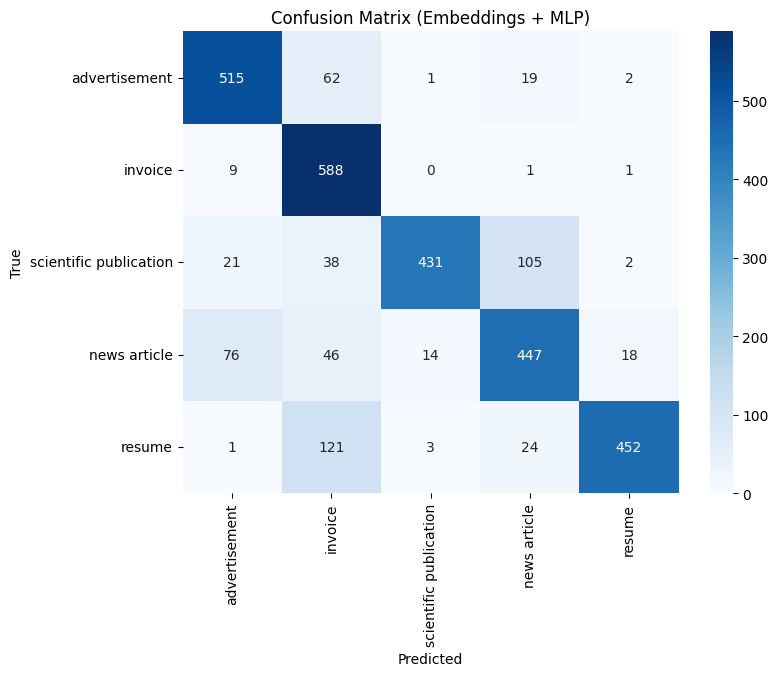

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id2label[i] for i in sorted(id2label)],
    yticklabels=[id2label[i] for i in sorted(id2label)]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Embeddings + MLP)")
plt.show()


In [62]:
# =========================================================
# HYBRID PATH 1: Fine-tuned DiT + Embedding Reuse
# =========================================================

import os, random, torch, numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import accuracy_score
import faiss

# ---------------- CONFIG ---------------- #

DATA_DIR = "/kaggle/input/datasets/uditamin/rvl-cdip-small/data"
SAVE_DIR = "/kaggle/working"

LABELS = [
    "advertisement",
    "invoice",
    "scientific publication",
    "news article",
    "resume"
]

label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS = 6
LR = 3e-5

# ---------------- DATASET ---------------- #

class DocDataset(Dataset):
    def __init__(self, files, labels, processor):
        self.files = files
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        image = Image.open(self.files[idx]).convert("RGB")
        inputs = self.processor(image, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = torch.tensor(self.labels[idx])
        return inputs

# ---------------- SPLIT DATA ---------------- #

train_files, train_labels = [], []
test_files, test_labels = [], []

for label in LABELS:
    path = os.path.join(DATA_DIR, label)
    files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".tif")]
    random.shuffle(files)

    split = int(0.8 * len(files))
    train, test = files[:split], files[split:]

    train_files += train
    train_labels += [label2id[label]] * len(train)

    test_files += test
    test_labels += [label2id[label]] * len(test)

# ---------------- LOAD DiT ---------------- #

processor = AutoImageProcessor.from_pretrained("microsoft/dit-base")

model = AutoModelForImageClassification.from_pretrained(
    "microsoft/dit-base",
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label
).to(DEVICE)

# ---------------- TRAIN ---------------- #

train_ds = DocDataset(train_files, train_labels, processor)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

from tqdm import tqdm

print("\n🚀 Fine-tuning DiT \n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        leave=False
    )

    for batch in progress_bar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Show live loss
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Avg Loss: {avg_loss:.4f}")


# ---------------- SAVE MODEL ---------------- #

torch.save(model.state_dict(), f"{SAVE_DIR}/dit_finetuned.pth")
print("✅ Fine-tuned DiT saved")

# =========================================================
# 🔥 EMBEDDING REUSE FROM FINE-TUNED DiT
# =========================================================

model.eval()
embeddings, labels = [], []

def extract_embedding(img_path):
    image = Image.open(img_path).convert("RGB")
    inputs = processor(image, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.base_model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :]   # CLS token

    return emb.cpu().numpy()[0]

print("\n📦 Extracting embeddings from fine-tuned DiT...\n")

for path, lab in zip(train_files, train_labels):
    emb = extract_embedding(path)
    embeddings.append(emb)
    labels.append(lab)

X = np.array(embeddings, dtype="float32")
y = np.array(labels)

# ---------------- SAVE EMBEDDINGS ---------------- #

np.save(f"{SAVE_DIR}/finetuned_embeddings.npy", X)
np.save(f"{SAVE_DIR}/finetuned_labels.npy", y)

# ---------------- BUILD FAISS ---------------- #

faiss.normalize_L2(X)
index = faiss.IndexFlatIP(X.shape[1])
index.add(X)
faiss.write_index(index, f"{SAVE_DIR}/finetuned_faiss.index")



Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/dit-base and are newly initialized: ['beit.pooler.layernorm.bias', 'beit.pooler.layernorm.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Fine-tuning DiT 



Epoch 1/6 | Avg Loss: 0.4047


Epoch 2/6 | Avg Loss: 0.1901


Epoch 3/6 | Avg Loss: 0.1281


Epoch 4/6 | Avg Loss: 0.1011


Epoch 5/6 | Avg Loss: 0.0791


Epoch 6/6 | Avg Loss: 0.0688
✅ Fine-tuned DiT saved

📦 Extracting embeddings from fine-tuned DiT...



Total test documents: 2997


Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/dit-base and are newly initialized: ['beit.pooler.layernorm.bias', 'beit.pooler.layernorm.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🧪 Running classification testing...

✅ Accuracy: 0.985985985985986

📄 Classification Report:

                        precision    recall  f1-score   support

         advertisement       0.98      0.98      0.98       599
               invoice       0.99      1.00      0.99       599
scientific publication       0.98      0.99      0.99       597
          news article       0.98      0.97      0.98       601
                resume       1.00      0.99      0.99       601

              accuracy                           0.99      2997
             macro avg       0.99      0.99      0.99      2997
          weighted avg       0.99      0.99      0.99      2997



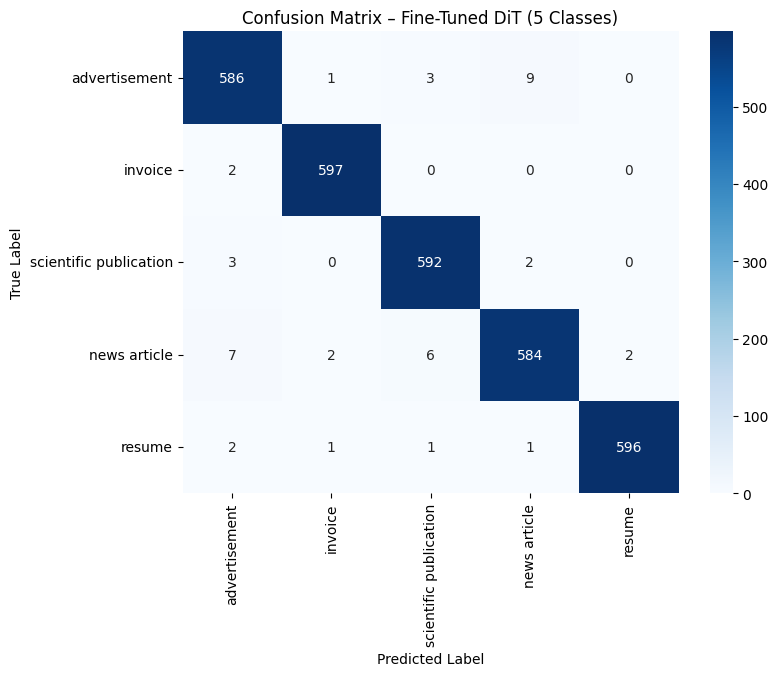

In [63]:
# =========================================================
# TESTING: Fine-Tuned DiT (Classification Evaluation)
# =========================================================

import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------- CONFIG ---------------- #

DATA_DIR = "/kaggle/input/datasets/uditamin/rvl-cdip-small/data"
SAVE_DIR = "/kaggle/working"

LABELS = [
    "advertisement",
    "invoice",
    "scientific publication",
    "news article",
    "resume"
]

label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16

# ---------------- DATASET ---------------- #

class DocDataset(Dataset):
    def __init__(self, files, labels, processor):
        self.files = files
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        image = Image.open(self.files[idx]).convert("RGB")
        inputs = self.processor(image, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = torch.tensor(self.labels[idx])
        return inputs

# ---------------- PREPARE TEST DATA ---------------- #

test_files, test_labels = [], []

for label in LABELS:
    class_path = os.path.join(DATA_DIR, label)
    files = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.endswith(".tif")]

    split = int(0.8 * len(files))
    test = files[split:]

    test_files.extend(test)
    test_labels.extend([label2id[label]] * len(test))

print(f"Total test documents: {len(test_files)}")

# ---------------- LOAD MODEL ---------------- #

processor = AutoImageProcessor.from_pretrained("microsoft/dit-base")

model = AutoModelForImageClassification.from_pretrained(
    "microsoft/dit-base",
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label
).to(DEVICE)

model.load_state_dict(torch.load(f"{SAVE_DIR}/dit_finetuned.pth"))
model.eval()

# ---------------- DATALOADER ---------------- #

test_dataset = DocDataset(test_files, test_labels, processor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ---------------- TESTING ---------------- #

y_true, y_pred = [], []

print("\n🧪 Running classification testing...\n")

with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].cpu().numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items() if k != "labels"}

        outputs = model(**batch)
        preds = outputs.logits.argmax(dim=1).cpu().numpy()

        y_true.extend(labels)
        y_pred.extend(preds)

# ---------------- METRICS ---------------- #

print("✅ Accuracy:", accuracy_score(y_true, y_pred))

print("\n📄 Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS
    )
)

# ---------------- CONFUSION MATRIX ---------------- #

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Fine-Tuned DiT (5 Classes)")
plt.show()


**Testing with single document (embeddings+MLP)**

In [80]:
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import torch
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load DiT backbone
processor = AutoImageProcessor.from_pretrained("microsoft/dit-base")
dit_model = AutoModel.from_pretrained("microsoft/dit-base").to(DEVICE)
dit_model.eval()

# Load trained classifier
model = MLP(dit_model.config.hidden_size, 5).to(DEVICE)
model.load_state_dict(torch.load("/kaggle/working/mlp_classifier.pth"))
model.eval()

id2label = np.load(
    "/kaggle/working/id2label.npy",
    allow_pickle=True
).item()


Some weights of BeitModel were not initialized from the model checkpoint at microsoft/dit-base and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
!apt-get install poppler-utils
!pip install pdf2image


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpoppler-dev libpoppler-private-dev libpoppler118
The following NEW packages will be installed:
  poppler-utils
The following packages will be upgraded:
  libpoppler-dev libpoppler-private-dev libpoppler118
3 upgraded, 1 newly installed, 0 to remove and 120 not upgraded.
Need to get 1,469 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-private-dev amd64 22.02.0-2ubuntu0.12 [199 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-dev amd64 22.02.0-2ubuntu0.12 [5,186 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler118 amd64 22.02.0-2ubuntu0.12 [1,079 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched

In [15]:
from pdf2image import convert_from_path
import os

def pdf_to_images(pdf_path, output_dir="/kaggle/working/pdf_pages"):
    os.makedirs(output_dir, exist_ok=True)
    pages = convert_from_path(pdf_path, dpi=200)

    image_paths = []
    for i, page in enumerate(pages):
        img_path = f"{output_dir}/page_{i}.png"
        page.save(img_path, "PNG")
        image_paths.append(img_path)

    return image_paths


In [16]:
def classify_image(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(image, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = dit_model(**inputs)
        embedding = outputs.last_hidden_state[:, 0, :]
        logits = model(embedding)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy()[0]


In [17]:
import numpy as np

def classify_pdf(pdf_path):
    image_paths = pdf_to_images(pdf_path)

    all_probs = []

    for img in image_paths:
        _, probs = classify_image(img)
        all_probs.append(probs)

    avg_probs = np.mean(all_probs, axis=0)
    final_pred = np.argmax(avg_probs)

    return id2label[final_pred], avg_probs


In [83]:
pdf_path = "/kaggle/input/test-documents/GMMDC-Media-Articles-2019.pdf"

predicted_class, confidence = classify_pdf(pdf_path)

print("📄 PDF predicted as:", predicted_class)


📄 PDF predicted as: advertisement


**Testing with single document (fine tuned dit+faiss)**

In [72]:
# =========================================================
# SINGLE PDF TESTING – Fine-Tuned DiT + FAISS (HYBRID)
# =========================================================

import torch
import numpy as np
import faiss
from PIL import Image
from pdf2image import convert_from_path
from transformers import AutoImageProcessor, AutoModelForImageClassification
from collections import Counter

# ---------------- CONFIG ---------------- #

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = "/kaggle/working"
TOP_K = 5

LABELS = [
    "advertisement",
    "invoice",
    "scientific publication",
    "news article",
    "resume"
]

id2label = {i: l for i, l in enumerate(LABELS)}

# ---------------- LOAD FAISS DATA ---------------- #

X_db = np.load(f"{SAVE_DIR}/finetuned_embeddings.npy")
y_db = np.load(f"{SAVE_DIR}/finetuned_labels.npy")

index = faiss.read_index(f"{SAVE_DIR}/finetuned_faiss.index")

# ---------------- LOAD FINE-TUNED DiT ---------------- #

processor = AutoImageProcessor.from_pretrained("microsoft/dit-base")

model = AutoModelForImageClassification.from_pretrained(
    "microsoft/dit-base",
    num_labels=len(LABELS)
).to(DEVICE)

model.load_state_dict(torch.load(f"{SAVE_DIR}/dit_finetuned.pth"))
model.eval()

# ---------------- PDF → IMAGES ---------------- #

def pdf_to_images(pdf_path, dpi=200):
    pages = convert_from_path(pdf_path, dpi=dpi)
    return pages

# ---------------- CLS EMBEDDING ---------------- #

def get_cls_embedding(image):
    inputs = processor(image, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.base_model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :]  # CLS

    emb = emb.cpu().numpy().astype("float32")
    faiss.normalize_L2(emb)
    return emb

# ---------------- PDF + FAISS TESTING ---------------- #

def test_pdf_with_faiss(pdf_path, top_k=TOP_K):
    pages = pdf_to_images(pdf_path)
    print(f"Total pages: {len(pages)}")

    all_page_votes = []

    for i, page in enumerate(pages, 1):
        query_emb = get_cls_embedding(page)
        scores, indices = index.search(query_emb, top_k)

        page_labels = [id2label[y_db[idx]] for idx in indices[0]]
        all_page_votes.extend(page_labels)


    # Majority voting across all pages
    final_label = Counter(all_page_votes).most_common(1)[0][0]
    
    print("Predicted Label:", final_label)
    

# ---------------- RUN TEST ---------------- #

pdf_path = "/kaggle/input/test-documents/Gatta_Poojitha_Naga_Kiranmai_resume.pdf"   
test_pdf_with_faiss(pdf_path)


Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/dit-base and are newly initialized: ['beit.pooler.layernorm.bias', 'beit.pooler.layernorm.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total pages: 1
Predicted Label: resume


In [2]:
!pip install streamlit pyngrok pdf2image faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 98.2 MB/s eta 0:00:00:00:010:01


In [22]:
%%writefile app.py

import streamlit as st
import torch
import numpy as np
import faiss
from pdf2image import convert_from_bytes
from transformers import AutoImageProcessor, AutoModelForImageClassification
from collections import Counter

# ---------------- CONFIG ---------------- #

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TOP_K = 5

LABELS = [
    "advertisement",
    "invoice",
    "scientific publication",
    "news article",
    "resume"
]

id2label = {i: l for i, l in enumerate(LABELS)}

BASE_PATH = "/kaggle/input/models/poojithagatta/embeddings/other/default/1"

# ---------------- LOAD MODEL ---------------- #

@st.cache_resource
def load_models():
    processor = AutoImageProcessor.from_pretrained("microsoft/dit-base")

    model = AutoModelForImageClassification.from_pretrained(
        "microsoft/dit-base",
        num_labels=len(LABELS)
    ).to(DEVICE)

    model.load_state_dict(torch.load(f"{BASE_PATH}/dit_finetuned.pth", map_location=DEVICE))
    model.eval()

    index = faiss.read_index(f"{BASE_PATH}/finetuned_faiss.index")
    y_db = np.load(f"{BASE_PATH}/finetuned_labels.npy")

    return processor, model, index, y_db

processor, model, index, y_db = load_models()

# ---------------- FUNCTIONS ---------------- #

def get_cls_embedding(image):
    inputs = processor(image, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.base_model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :]

    emb = emb.cpu().numpy().astype("float32")
    faiss.normalize_L2(emb)
    return emb


def classify_pdf(pdf_bytes):
    pages = convert_from_bytes(pdf_bytes)
    all_votes = []
    page_data = []

    for i, page in enumerate(pages):
        emb = get_cls_embedding(page)
        scores, indices = index.search(emb, TOP_K)

        labels = [id2label[y_db[idx]] for idx in indices[0]]
        all_votes.extend(labels)

        page_data.append((i + 1, page, labels))

    final_label = Counter(all_votes).most_common(1)[0][0]
    confidence = round(100 * all_votes.count(final_label) / len(all_votes), 2)

    return final_label, confidence, page_data, Counter(all_votes)

# ---------------- UI ---------------- #

st.set_page_config(page_title="AI Document Classifier", layout="wide")

# 🎨 PREMIUM CSS
st.markdown("""
<style>
body {
    background-color: #f8fafc;
}
.title {
    font-size: 42px;
    font-weight: 700;
    text-align: center;
    color: #1f2937;
}
.subtitle {
    text-align: center;
    font-size: 18px;
    color: #6b7280;
    margin-bottom: 30px;
}
.card {
    background: white;
    padding: 25px;
    border-radius: 15px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
}
.result {
    font-size: 28px;
    font-weight: bold;
    color: #2563eb;
}
.conf {
    font-size: 16px;
    color: #10b981;
}
.badge {
    display: inline-block;
    padding: 6px 12px;
    margin: 4px;
    background: #e0e7ff;
    border-radius: 8px;
    font-size: 13px;
}
</style>
""", unsafe_allow_html=True)

# Header
st.markdown('<div class="title">📄 Document Classifier</div>', unsafe_allow_html=True)

# Upload Section (centered)
col1, col2, col3 = st.columns([1,2,1])
with col2:
    uploaded_file = st.file_uploader("Upload your PDF", type=["pdf"])

if uploaded_file is not None:
    pdf_bytes = uploaded_file.read()

    col1, col2, col3 = st.columns([1,2,1])
    with col2:
        run = st.button("🚀 Classify Document", use_container_width=True)

    if run:
        with st.spinner("Analyzing document... ⏳"):
            final_label, confidence, page_data, vote_dist = classify_pdf(pdf_bytes)

        st.write("")

        # 🔥 RESULT CARDS (SIDE BY SIDE)
        col1, col2, col3 = st.columns(3)

        with col1:
            st.markdown(f"""
            <div class="card">
                <div class="result">📌 {final_label.upper()}</div>
                <div>Predicted Class</div>
            </div>
            """, unsafe_allow_html=True)

        with col2:
            st.markdown(f"""
            <div class="card">
                <div class="conf">Confidence: {confidence}%</div>
                <div>Model Certainty</div>
            </div>
            """, unsafe_allow_html=True)

        with col3:
            st.markdown(f"""
            <div class="card">
                <div>{len(page_data)}</div>
                <div>Total Pages</div>
            </div>
            """, unsafe_allow_html=True)

        st.write("---")


        # 📄 PAGE DISPLAY
        st.subheader("📑 Document Pages Analysis")

        for page_num, page, labels in page_data:
            st.markdown(f"### Page {page_num}")

            col1, col2 = st.columns([2,1])

            with col1:
                st.image(page, use_container_width=True)

            with col2:
                st.markdown("**Top Matches:**")
                for label in labels:
                    st.markdown(f'<span class="badge">{label}</span>', unsafe_allow_html=True)

            st.write("---")

Overwriting app.py


2026-04-19 09:51:00.733 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-19 09:51:00.869 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-19 09:51:01.006 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-19 09:51:01.139 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-19 09:51:01.270 

In [11]:
!pip install pyngrok

In [19]:
from pyngrok import ngrok

# 🔑 Add your authtoken here
ngrok.set_auth_token("3CZSK1rNBcBum8MpUKwcz14jdXD_79oyebTgbQwAACTnSkxs2")

# Start Streamlit
get_ipython().system_raw("streamlit run app.py --server.port 8501 &")

# Create public URL
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://9bd0-34-23-185-49.ngrok-free.app" -> "http://localhost:8501"


2026-04-19 09:43:26.160 Port 8501 is not available
2026-04-19 09:43:59.824 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
